### Useful Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Read Data

In [3]:
data = pd.read_csv(
    '//wsl.localhost/Ubuntu-22.04/home/ramon/projeto_bragg/BraggPeak_100MeV.csv',
    comment='#',
    header=None,
    names=['ix','iy','iz','dose'])

### Construction Depth Axis

In [4]:
n_bins = len(data)
thickness = 40
bin_size = thickness/n_bins
depth = np.linspace(bin_size/2, thickness - bin_size/2, n_bins)

### Normalizing by Maximum Dose

In [5]:
dose = np.array(data['dose'])
dose = dose[::-1]
dose_norm = dose / dose.max() * 100

### Calculating R80

In [6]:
idx_peak = np.argmax(dose_norm)
distal_dose = dose_norm[idx_peak:]
distal_prof = depth[idx_peak:]
r80 = np.interp(80, distal_dose[::-1], distal_prof[::-1])

### Calculating Distal Penumbra

In [7]:
r20 = np.interp(20.0, distal_dose[::-1], distal_prof[::-1])
penumbra = r20 - r80

### Comparing with NIST data

In [8]:
r_nist = 7.718
deviation = abs(r_nist - r80)/r_nist * 100

### Printing Results

In [9]:
print('=' * 45)
print('Simulation Results:')
print('=' * 45)
print(f'Peak Depth: {depth[idx_peak]:.2f} cm')
print(f'Simulated R80: {r80:.2f} cm')
print(f'Reference R80 NIST: {r_nist:.2f} cm')
print(f'Deviation Simulation vs NIST: {deviation:.2f}%')
print(f'Distal Penumbra: {penumbra:.2f} cm')
print(f'=' * 45)

Simulation Results:
Peak Depth: 7.15 cm
Simulated R80: 7.25 cm
Reference R80 NIST: 7.72 cm
Deviation Simulation vs NIST: 6.03%
Distal Penumbra: 0.13 cm


### Ploting Data

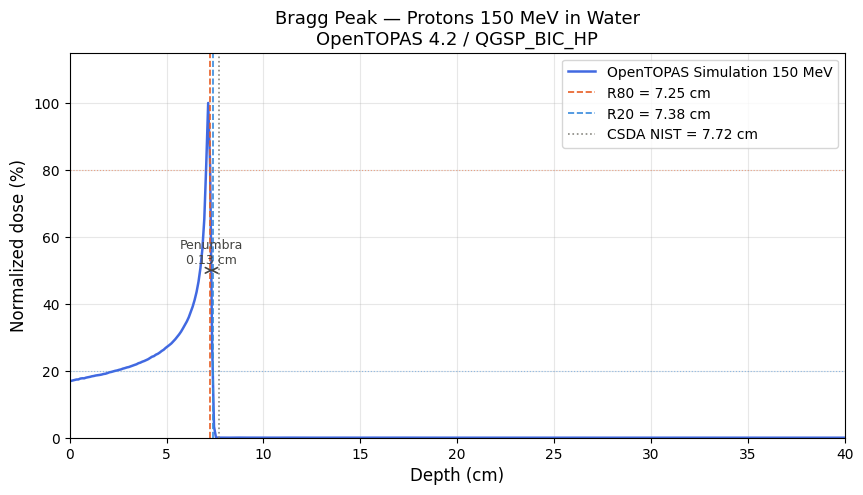

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(depth, dose_norm, color='royalblue', linewidth=1.8,
        label='OpenTOPAS Simulation 150 MeV')

ax.axvline(r80, color='#E85D24', linestyle='--', linewidth=1.2,
           label=f'R80 = {r80:.2f} cm')
ax.axvline(r20, color='#378ADD', linestyle='--', linewidth=1.2,
           label=f'R20 = {r20:.2f} cm')
ax.axvline(r_nist, color="#888780", linestyle=":", linewidth=1.2,
           label=f"CSDA NIST = {r_nist:.2f} cm")


ax.axhline(80, color="#E85D24", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(20, color="#378ADD", linestyle=":", linewidth=0.8, alpha=0.5)

ax.annotate("", xy=(r20, 50), xytext=(r80, 50),
            arrowprops=dict(arrowstyle="<->", color="#444441", lw=1.2))
ax.text((r80 + r20)/2, 52, f"Penumbra\n{penumbra:.2f} cm",
        ha="center", fontsize=9, color="#444441")

ax.set_xlabel("Depth (cm)", fontsize=12)
ax.set_ylabel("Normalized dose (%)", fontsize=12)
ax.set_title("Bragg Peak — Protons 150 MeV in Water\nOpenTOPAS 4.2 / QGSP_BIC_HP",
             fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, thickness)
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3)
